# Practical 2 — From Relationships to Predictive Models

**Course:** Machine Learning for Bioinformatics  
**Week 2 topics:** correlation, linear regression, residuals, assumptions, loss, evaluation

## Learning goals

By the end of this practical, you should be able to:

- distinguish description, inference, and prediction;
- inspect quantitative relationships before modelling;
- calculate and interpret Pearson and Spearman correlations;
- fit and interpret simple and multiple linear regression;
- calculate and visualize residuals;
- diagnose violations of linearity, homoscedasticity, and residual normality;
- explain why biological independence matters;
- encode categorical variables;
- interpret interaction terms;
- evaluate regression models using MAE, MSE, RMSE, and $R^2$;
- compare training and test performance;
- critically read model output rather than relying on a single metric.

---

## Guided dataset

We will use the **Palmer Penguins** dataset.

Main question:

> **Can we predict penguin body mass from morphological measurements and biological metadata?**

# 1. Setup

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import dcor
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 170926

# 2. Load and inspect data

For this practical, one row corresponds to one penguin.

Before fitting anything, we first inspect the structure of the data.

In [4]:
penguins = fetch_openml(name="penguins", as_frame=True)
df = penguins.frame.copy()

df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [4]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

# Universal biological data-preparation checklist


## Scientific purpose and provenance

- [ ] Is the biological question and prediction task stated clearly?
- [ ] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
- [ ] Do I know where the data came from, how they were generated, and under which license or access conditions they may be used?
- [ ] Have I recorded the data version, processing history, and transformations already applied?

## Table shape and identifiers

- [ ] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [ ] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
- [ ] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
- [ ] Can every feature and observation be traced back to its source?
- [ ] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?

## Types, values, and measurement meaning

- [ ] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [ ] Are units, scales, encodings, reference categories, and detection limits understood?
- [ ] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
- [ ] Are normalization, scaling, log transformation, and batch-correction steps documented?


In [5]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.0 KB


In [ ]:
print("Shape:", df.shape)
print("Column names are unique:", df.columns.is_unique)

True

In [6]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)
print("Constant columns:", [column for column in df.columns if df[column].nunique(dropna=False) <= 1])

Numeric columns: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical columns: ['species', 'island', 'sex']
Constant columns: []



## Missing values

- [ ] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [ ] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [ ] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
- [ ] Have I justified whether to retain, remove, or impute missing values?
- [ ] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?

## Replicates, dependence, and grouping

- [ ] Have I checked for exact duplicates and near-duplicate observations?
- [ ] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [ ] Is the independent biological unit identified by a grouping variable?
- [ ] Will all related observations and their derivatives remain in the same train/validation/test split?
- [ ] If I created augmented or synthetic observations, is their provenance recorded and reproducible?


In [7]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_row = df.isna().sum(axis=1)

display(missing_by_column.to_frame("missing_count"))
display((missing_by_column / len(df)).to_frame("missing_fraction"))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))
print("Rows with more than one missing value:", int((missing_by_row > 1).sum()))

,missing_count
sex,10
culmen_depth_mm,2
culmen_length_mm,2
flipper_length_mm,2
body_mass_g,2
island,0
species,0


,missing_fraction
sex,0.029070
culmen_depth_mm,0.005814
culmen_length_mm,0.005814
flipper_length_mm,0.005814
body_mass_g,0.005814
island,0.000000
species,0.000000


Rows with at least one missing value: 10
Rows with more than one missing value: 2


In [8]:
# Check exact duplicates and visible grouping variables.
print("Exact duplicate rows:", int(df.duplicated().sum()))

for column in ["species", "island", "sex"]:
    print(f"\nCounts for {column}:")
    display(df[column].value_counts(dropna=False).to_frame("count"))

print("\nCounts by species and island:")
display(df.groupby(["species", "island"], observed=False).size().rename("count").to_frame())


Exact duplicate rows: 0

Counts for species:


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68



Counts for island:


,count
island,
Biscoe,168
Dream,124
Torgersen,52



Counts for sex:


,count
sex,
MALE,168
FEMALE,165
NaN,10
_,1



Counts by species and island:


count
species   island          
Adelie    Biscoe        44
          Dream         56
          Torgersen     52
Chinstrap Biscoe         0
          Dream         68
          Torgersen      0
Gentoo    Biscoe       124
          Dream          0
          Torgersen      0


## Target, leakage, and study design

- [ ] Is the target defined before modelling, with its classes or values checked for balance and validity?
- [ ] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
- [ ] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [ ] Have I checked whether the target is associated with a technical or grouping variable?
- [ ] Does the planned split represent the biological generalization question?


In [12]:
TARGET = "body_mass_g"

for grouping_variable in ["species", "island", "sex"]:
    print(f"\nTarget summary by {grouping_variable}:")
    display(df.groupby(grouping_variable, observed=False)[TARGET].agg(["count", "mean", "std"]))


Target summary by species:


,count,mean,std
species,,,
Adelie,151,3700.662252,458.566126
Chinstrap,68,3733.088235,384.335081
Gentoo,123,5076.016260,504.116237



Target summary by island:


,count,mean,std
island,,,
Biscoe,167,4716.017964,782.855743
Dream,124,3712.903226,416.644112
Torgersen,51,3706.372549,445.107940



Target summary by sex:


,count,mean,std
sex,,,
FEMALE,165,3862.272727,666.172050
MALE,168,4545.684524,787.628884
_,1,4875.000000,NaN



## Reproducibility and decision record

- [ ] Are random seeds, software versions, file names, and input/output shapes recorded?
- [ ] Are all preprocessing steps placed in a reproducible pipeline?
- [ ] Have I recorded unresolved data-quality concerns and the decisions made about them?
- [ ] Can another person explain what each row, column, feature, target, and grouping variable means?

## Short preparation summary

Before modelling, write down:

- biological unit: ...
- number of observations and features: ...
- target and feature definition: ...
- missing-value decision: ...
- replicate/grouping decision: ...
- main confounder or possible leakage source: ...
- train/test split and why it is appropriate: ...
- remaining concerns: ...


# 3. Descriptive relationships

In [9]:
df["body_mass_g"].describe()

count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

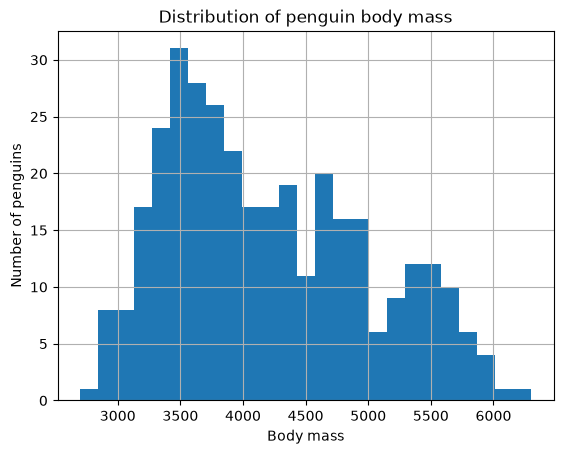

In [10]:
df["body_mass_g"].hist(bins=25)
plt.xlabel("Body mass")
plt.ylabel("Number of penguins")
plt.title("Distribution of penguin body mass")
plt.show()

In [11]:
numeric_cols = ["body_mass_g","flipper_length_mm","culmen_length_mm","culmen_depth_mm"]

df[numeric_cols].describe()

,body_mass_g,flipper_length_mm,culmen_length_mm,culmen_depth_mm
count,342.000000,342.000000,342.000000,342.000000
mean,4201.754386,200.915205,43.921930,17.151170
std,801.954536,14.061714,5.459584,1.974793
min,2700.000000,172.000000,32.100000,13.100000
25%,3550.000000,190.000000,39.225000,15.600000
50%,4050.000000,197.000000,44.450000,17.300000
75%,4750.000000,213.000000,48.500000,18.700000
max,6300.000000,231.000000,59.600000,21.500000


## 3.1 Visualize candidate relationships

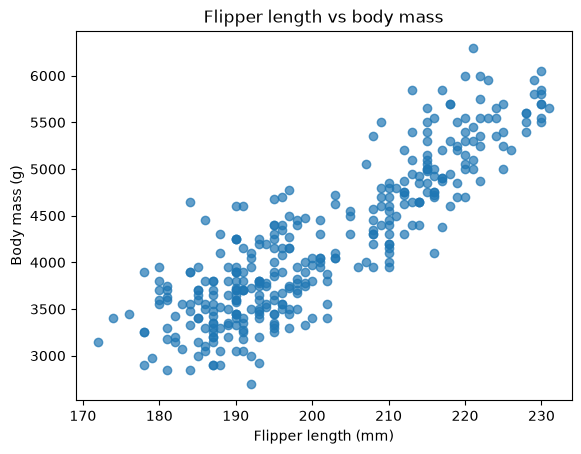

In [12]:
plot_df = df.dropna(subset=["body_mass_g", "flipper_length_mm"])

plt.scatter(plot_df["flipper_length_mm"], plot_df["body_mass_g"], alpha=0.7)
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Flipper length vs body mass")
plt.show()

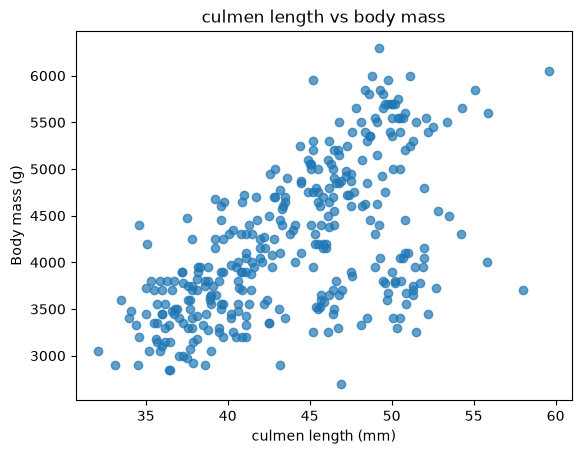

In [13]:
plot_df = df.dropna(subset=["body_mass_g", "culmen_length_mm"])

plt.scatter(plot_df["culmen_length_mm"], plot_df["body_mass_g"], alpha=0.7)
plt.xlabel("culmen length (mm)")
plt.ylabel("Body mass (g)")
plt.title("culmen length vs body mass")
plt.show()

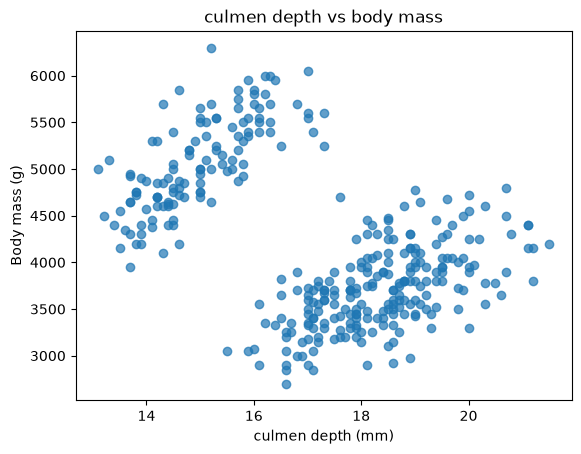

In [14]:
plot_df = df.dropna(subset=["body_mass_g", "culmen_depth_mm"])

plt.scatter(plot_df["culmen_depth_mm"],plot_df["body_mass_g"], alpha=0.7)
plt.xlabel("culmen depth (mm)")
plt.ylabel("Body mass (g)")
plt.title("culmen depth vs body mass")
plt.show()

Which predictor looks most promising for a simple linear regression?

Does visual structure suggest that all relationships are equally linear?

# 4. Correlation

Correlation quantifies association.

Pearson correlation is primarily a measure of **linear** association.

Spearman correlation is based on ranks and captures **monotonic** association.

In [15]:
corr_df = df[numeric_cols].dropna()
corr_df.corr(method="pearson")

,body_mass_g,flipper_length_mm,culmen_length_mm,culmen_depth_mm
body_mass_g,1.000000,0.871202,0.595110,-0.471916
flipper_length_mm,0.871202,1.000000,0.656181,-0.583851
culmen_length_mm,0.595110,0.656181,1.000000,-0.235053
culmen_depth_mm,-0.471916,-0.583851,-0.235053,1.000000


In [16]:
corr_df.corr(method="spearman")

,body_mass_g,flipper_length_mm,culmen_length_mm,culmen_depth_mm
body_mass_g,1.000000,0.839974,0.583800,-0.432372
flipper_length_mm,0.839974,1.000000,0.672772,-0.523267
culmen_length_mm,0.583800,0.672772,1.000000,-0.221749
culmen_depth_mm,-0.432372,-0.523267,-0.221749,1.000000


### Distance correlation

Pearson correlation measures linear association. Spearman correlation measures monotone association after replacing values by ranks. **Distance correlation** (dCor) asks a broader question: are the two variables dependent at all? It can detect some non-linear and non-monotone relationships.

For observations $x_1, x_n$ and $y_1,  y_n$, construct two distance matrices:

$$A_{ij} = |x_i - x_j|, \qquad B_{ij} = |y_i - y_j|.$$

The matrices are **double-centered** so that row and column averages are removed. The centered matrices are then compared:

$$\mathcal{V}^2(X,Y) = \frac{1}{n^2} \sum_{i,j} A^c_{ij} B^c_{ij}.$$

Distance correlation normalizes this distance covariance by the corresponding distance variances:

$$\operatorname{dCor}(X,Y) = \sqrt{\frac{\mathcal{V}^2(X,Y)}{\sqrt{\mathcal{V}^2(X,X)\mathcal{V}^2(Y,Y)}}}.$$

The `dcor` library performs this calculation for us. In the population, dCor is zero exactly when variables are independent; in a finite sample it is an estimate.

In [17]:
target = "body_mass_g"
features = ["flipper_length_mm", "culmen_length_mm", "culmen_depth_mm"]
dcor_results = []
for feature in features:
    pair = corr_df[[feature, target]].dropna()
    dcor_results.append({
        "feature": feature,
        "Pearson": pair[feature].corr(pair[target], method="pearson"),
        "Spearman": pair[feature].corr(pair[target], method="spearman"),
        "Distance correlation": dcor.distance_correlation(
            pair[feature].to_numpy(), pair[target].to_numpy()),})

pd.DataFrame(dcor_results).set_index("feature").round(3)

,Pearson,Spearman,Distance correlation
feature,,,
flipper_length_mm,0.871,0.840,0.867
culmen_length_mm,0.595,0.584,0.587
culmen_depth_mm,-0.472,-0.432,0.614


Interpret the three measures together. A high distance correlation means that dependence is present, not that one variable causes the other. Because the penguins belong to visibly different species and islands, repeat the analysis within species and compare the results with the pooled analysis.

### Questions

- Which variable has the strongest Pearson correlation with `body_mass_g`?
- Is the ranking identical for Spearman correlation?
- Is distance correlation different and why?


# 5. Confounding and biological structure

A global relationship can partly arise because biological groups differ from each other.

Here, species is an obvious candidate.

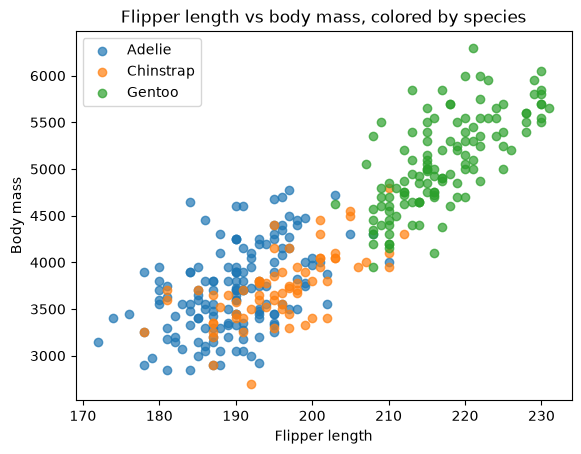

In [18]:
species_colors = {}
for species, group in df.dropna(
    subset=["body_mass_g", "flipper_length_mm", "species"]
).groupby("species"):
    plt.scatter(group["flipper_length_mm"], group["body_mass_g"], label=species, alpha=0.7)

plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.title("Flipper length vs body mass, colored by species")
plt.legend()
plt.show()

In [19]:
pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


### Discussion

A useful question is:

> Is the global relationship driven by individual-level morphology, species differences, or both?

This is the same conceptual problem as the batch/confounding discussion from Week 1.

# 6. Simple linear regression

We begin with:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

where:

- $x$ = flipper length;
- $\hat{y}$ = predicted body mass.

In [20]:
simple_df = df[["flipper_length_mm", "body_mass_g"]].dropna()

X_simple = simple_df[["flipper_length_mm"]]
y_simple = simple_df["body_mass_g"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)

print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

Intercept: -5780.831358077066
Slope: 49.68556640610011


### Interpret the coefficient

For each additional 1 mm of flipper length, the model predicts an average change of approximately ___ g in body mass.


## 6.1 Plot the fitted line

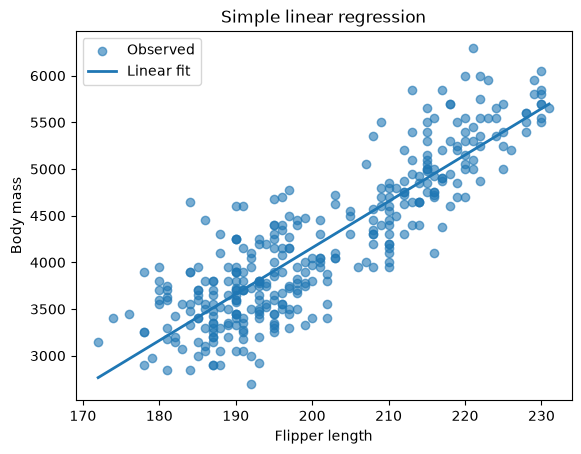

In [21]:
y_hat_simple = simple_model.predict(X_simple)

order = np.argsort(X_simple["flipper_length_mm"].to_numpy())

plt.scatter(X_simple["flipper_length_mm"], y_simple, alpha=0.6, label="Observed")

plt.plot(X_simple["flipper_length_mm"].to_numpy()[order], y_hat_simple[order], linewidth=2, label="Linear fit")

plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.title("Simple linear regression")
plt.legend()
plt.show()

# 7. Predictions and residuals

Residual:

$$
e_i = y_i - \hat{y}_i
$$

Residuals tell us what the model fails to explain.

In [22]:
residuals = y_simple.to_numpy() - y_hat_simple

residual_df = pd.DataFrame({
    "observed": y_simple.to_numpy(),
    "predicted": y_hat_simple,
    "residual": residuals})

residual_df.head()

,observed,predicted,residual
0,3750.0,3212.256161,537.743839
1,3800.0,3460.683993,339.316007
2,3250.0,3907.854091,-657.854091
3,3450.0,3808.482958,-358.482958
4,3650.0,3659.426259,-9.426259


## 7.2 Residuals vs predicted

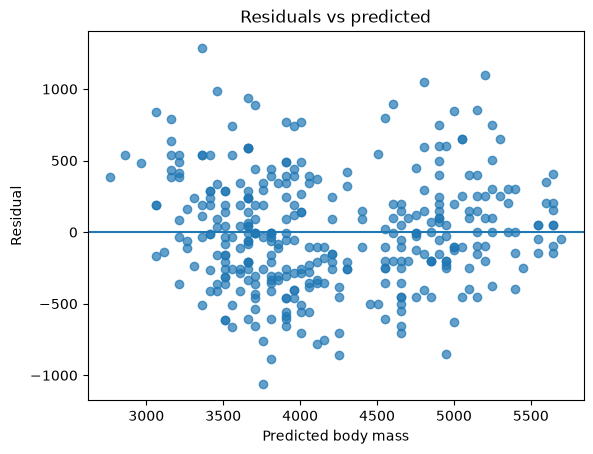

In [23]:
plt.scatter(
    residual_df["predicted"],
    residual_df["residual"],
    alpha=0.7)

plt.axhline(0)
plt.xlabel("Predicted body mass")
plt.ylabel("Residual")
plt.title("Residuals vs predicted")
plt.show()

### Questions

- Are residuals centered approximately around zero?
- Is there an obvious curved pattern?
- Does residual variance increase with predicted values?
- Are there unusually large residuals?

# 8. Regression assumptions

We will inspect four ideas:

1. linearity;
2. independence;
3. homoscedasticity;
4. residual normality.

Later we also look at multicollinearity.

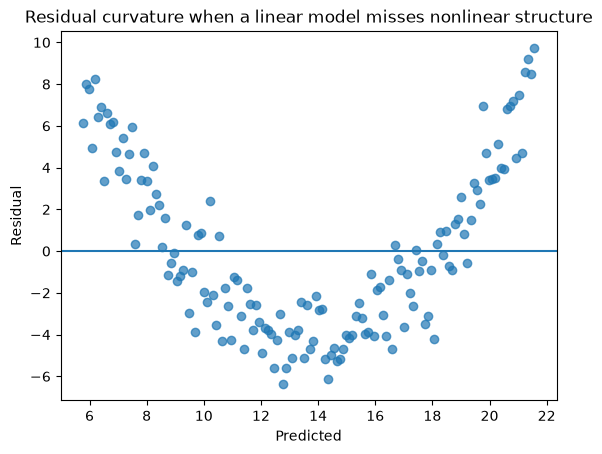

In [24]:
rng = np.random.default_rng(RANDOM_STATE)

x_demo = np.linspace(0, 10, 150)
y_demo = 2 + 1.5 * x_demo + 0.5 * (x_demo - 5)**2 + rng.normal(0, 1.5, len(x_demo))

demo_model = LinearRegression()
demo_model.fit(x_demo.reshape(-1, 1), y_demo)

demo_pred = demo_model.predict(x_demo.reshape(-1, 1))
demo_resid = y_demo - demo_pred

plt.scatter(demo_pred, demo_resid, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual curvature when a linear model misses nonlinear structure")
plt.show()

## 8.2 Homoscedasticity

Homoscedasticity means that residual variance is approximately constant across fitted values.

We create a second teaching example with increasing variance.

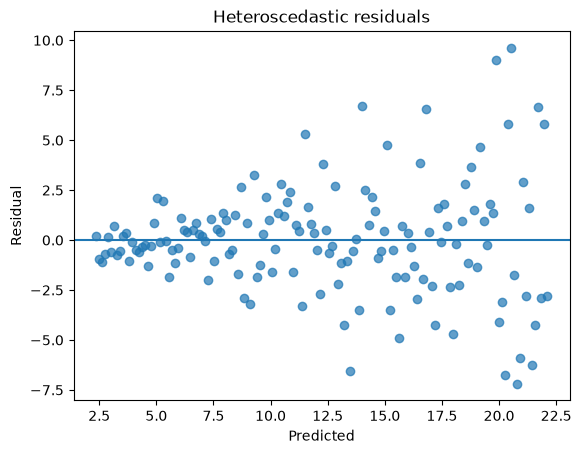

In [25]:
x_demo = np.linspace(0, 10, 150)
noise_scale = 0.4 + 0.4 * x_demo
y_hetero = 2 + 2 * x_demo + rng.normal(0, noise_scale)

hetero_model = LinearRegression()
hetero_model.fit(x_demo.reshape(-1, 1), y_hetero)

hetero_pred = hetero_model.predict(x_demo.reshape(-1, 1))
hetero_resid = y_hetero - hetero_pred

plt.scatter(hetero_pred, hetero_resid, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Heteroscedastic residuals")
plt.show()

## 8.3 Residual normality

For classical OLS inference, we are interested in the **distribution of residuals**, not whether the predictors themselves are normally distributed.

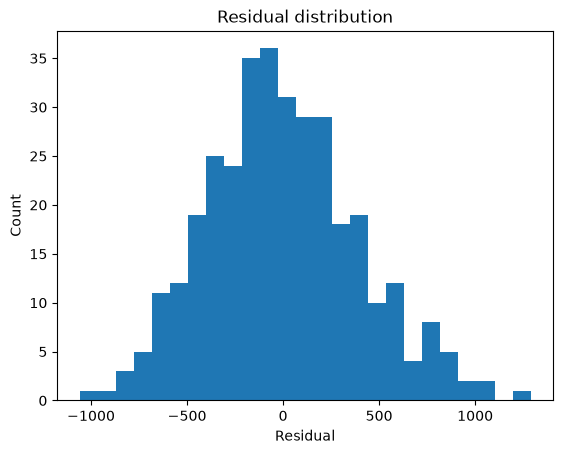

In [26]:
plt.hist(residuals, bins=25)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()

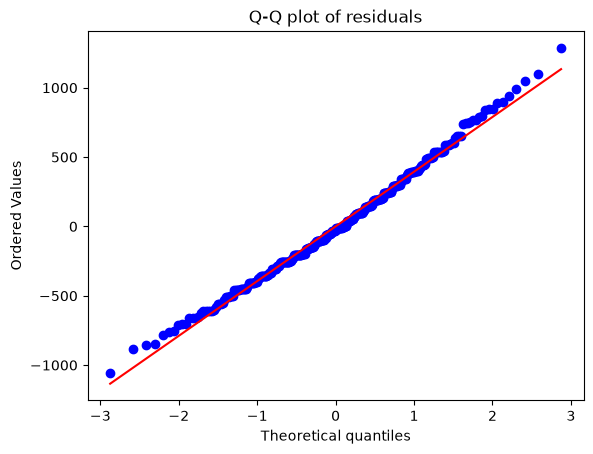

In [27]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.show()

## 8.4 Independence

For Palmer Penguins, each row is approximately one biological individual.


# 9. Multiple linear regression

Now fit:

$$
\hat{y}
=
\beta_0
+
\beta_1 \text{Flipper}
+
\beta_2 \text{CulmenLength}
+
\beta_3 \text{CulmenDepth}
$$

In [28]:
multiple_cols = ["flipper_length_mm",
    "culmen_length_mm",
    "culmen_depth_mm",
    "body_mass_g"]

multiple_df = df[multiple_cols].dropna()

X_multiple = multiple_df[["flipper_length_mm", "culmen_length_mm", "culmen_depth_mm"]]
y_multiple = multiple_df["body_mass_g"]

multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y_multiple)

coef_table = pd.DataFrame({"feature": X_multiple.columns, "coefficient": multiple_model.coef_})

coef_table

,feature,coefficient
0,flipper_length_mm,50.269222
1,culmen_length_mm,4.161820
2,culmen_depth_mm,20.049533


In [29]:
print("Intercept:", multiple_model.intercept_)

Intercept: -6424.764698098594


### Interpretation

In multiple regression, each coefficient is interpreted **conditional on the other variables in the model**.

That is different from a simple pairwise correlation.

# 9.5 Symbolic regression with Palmer Penguins

In ordinary regression, we choose the form of the model first (for example, a straight line) and estimate its coefficients. **Symbolic regression** searches over candidate expressions as well as their coefficients. The result is intended to be a compact, human-readable equation.

Here the biological question is:

> Can a simple equation describe penguin body mass from different morphological measurements?

We will repeat the same small search for three predictors: `flipper_length_mm`, `culmen_length_mm`, and `culmen_depth_mm`. The candidate expressions contain powers and a few transformations. This is an illustration of the idea.

,predictor,best equation,AIC
0,flipper_length_mm,body_mass_g ~= 4417.9 +740.9*x -42.2*x^3 -349....,4061.6
1,culmen_length_mm,body_mass_g ~= 3089.8 +386.7*x^2 +652.1*sin(x)...,4417.3
2,culmen_depth_mm,body_mass_g ~= 3629.5 +807.7*x +708.9*sqrt(|x|...,4402.1


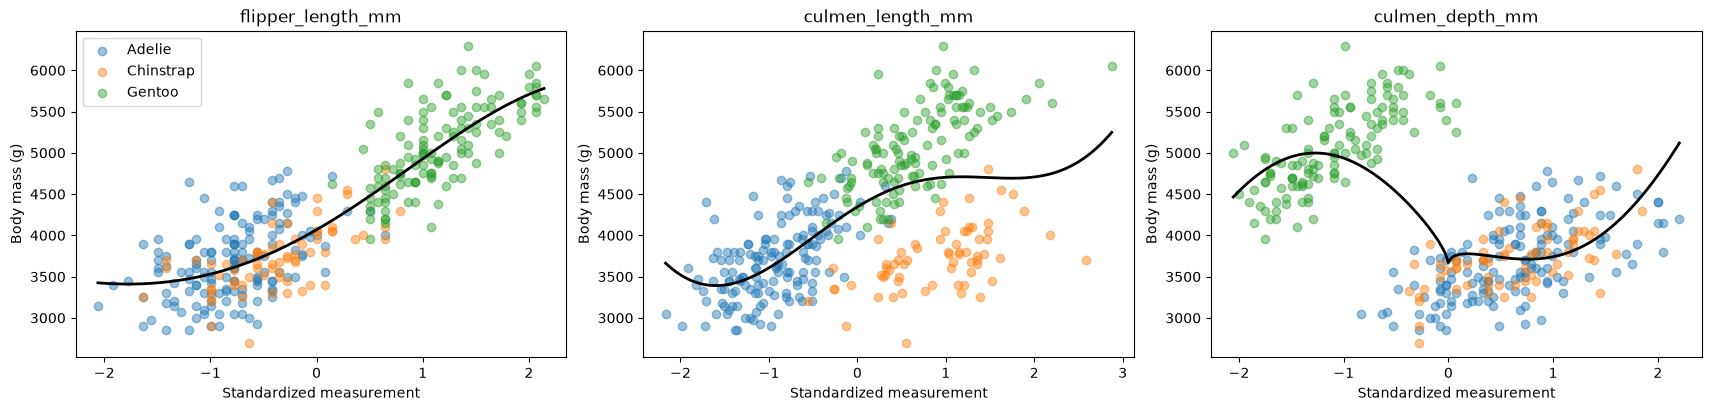

In [30]:
import itertools

symbolic_predictors = [
    "flipper_length_mm",
    "culmen_length_mm",
    "culmen_depth_mm"]


def search_symbolic_expression(x, y):
    # Standardization makes coefficients comparable and improves numerical stability.
    x_mean = x.mean()
    x_std = x.std()
    x = (x - x_mean) / x_std
    candidate_terms = {
        "x": x,
        "x^2": x**2,
        "x^3": x**3,
        "sqrt(|x|)": np.sqrt(np.abs(x)),
        "log(1+|x|)": np.log1p(np.abs(x)),
        "sin(x)": np.sin(x),
        "cos(x)": np.cos(x),}

    candidates = []
    n_observations = len(y)
    for n_terms in range(1, 4):
        for names in itertools.combinations(candidate_terms, n_terms):
            X_candidate = np.column_stack([candidate_terms[name] for name in names])
            candidate_model = LinearRegression().fit(X_candidate, y)
            predictions = candidate_model.predict(X_candidate)
            rss = np.sum((y - predictions) ** 2)
            n_parameters = n_terms + 1
            aic = n_observations * np.log(rss / n_observations) + 2 * n_parameters
            candidates.append((aic, names, candidate_model, x_mean, x_std))

    best_aic, best_names, best_model, x_mean, x_std = min(
        candidates, key=lambda item: item[0]
    )
    equation = f"body_mass_g ~= {best_model.intercept_:.1f}"
    for coefficient, name in zip(best_model.coef_, best_names):
        equation += f" {coefficient:+.1f}*{name}"
    return best_aic, best_names, best_model, x_mean, x_std, equation


symbolic_results = []
symbolic_models = {}
for predictor in symbolic_predictors:
    subset = df[[predictor, "body_mass_g", "species"]].dropna().copy()
    x_raw = subset[predictor].to_numpy(dtype=float)
    y = subset["body_mass_g"].to_numpy(dtype=float)
    result = search_symbolic_expression(x_raw, y)
    best_aic, best_names, best_model, x_mean, x_std, equation = result
    symbolic_models[predictor] = {
        "subset": subset,
        "best_names": best_names,
        "model": best_model,
        "x_mean": x_mean,
        "x_std": x_std,
    }
    symbolic_results.append({
        "predictor": predictor,
        "best equation": equation,
        "AIC": round(best_aic, 1),
    })

display(pd.DataFrame(symbolic_results))

fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
for axis, predictor in zip(axes, symbolic_predictors):
    details = symbolic_models[predictor]
    subset = details["subset"]
    x_raw = subset[predictor].to_numpy(dtype=float)
    x_scaled = (x_raw - details["x_mean"]) / details["x_std"]
    y = subset["body_mass_g"].to_numpy(dtype=float)
    x_grid = np.linspace(x_scaled.min(), x_scaled.max(), 300)
    grid_terms = {
        "x": x_grid,
        "x^2": x_grid**2,
        "x^3": x_grid**3,
        "sqrt(|x|)": np.sqrt(np.abs(x_grid)),
        "log(1+|x|)": np.log1p(np.abs(x_grid)),
        "sin(x)": np.sin(x_grid),
        "cos(x)": np.cos(x_grid),
    }
    X_grid = np.column_stack([grid_terms[name] for name in details["best_names"]])
    for species, species_df in subset.groupby("species", observed=False):
        species_x = (species_df[predictor] - details["x_mean"]) / details["x_std"]
        axis.scatter(species_x, species_df["body_mass_g"], alpha=0.45, label=species)
    axis.plot(x_grid, details["model"].predict(X_grid), color="black", linewidth=2)
    axis.set_title(predictor)
    axis.set_xlabel("Standardized measurement")
    axis.set_ylabel("Body mass (g)")
axes[0].legend()
plt.show()

Discussion:

- Which predictor produces the simplest or most plausible equation?
- Does the best equation look stable across species?
- Does a lower AIC automatically make an equation biologically meaningful?
- What additional variables or validation would be needed before using the equation for prediction?

# 10. Multicollinearity

Highly correlated predictors can destabilize individual coefficient estimates.

This is especially common in biological datasets.

In [31]:
X_multiple.corr()

,flipper_length_mm,culmen_length_mm,culmen_depth_mm
flipper_length_mm,1.000000,0.656181,-0.583851
culmen_length_mm,0.656181,1.000000,-0.235053
culmen_depth_mm,-0.583851,-0.235053,1.000000


### Questions

- Could two predictors be carrying similar information?
- Can prediction still be acceptable even when coefficient interpretation becomes unstable?

# 11. Categorical predictors

Now add `species` and `sex`.

Categorical predictors need a numerical representation.

We use one-hot encoding inside an sklearn pipeline.

In [32]:
model_df = df[
    ["flipper_length_mm",
        "culmen_length_mm",
        "culmen_depth_mm",
        "species",
        "sex",
        "body_mass_g"]].dropna()

X = model_df.drop(columns="body_mass_g")
y = model_df["body_mass_g"]

numeric_features = ["flipper_length_mm",
    "culmen_length_mm",
    "culmen_depth_mm"]

categorical_features = ["species","sex"]

preprocessor = ColumnTransformer(
    transformers=[("num", "passthrough", numeric_features),
        ("cat",OneHotEncoder(drop="first", handle_unknown="ignore"),categorical_features)])

full_model = Pipeline(
    steps=[("preprocess", preprocessor),
        ("model", LinearRegression())])

full_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['flipper_length_mm','culmen_length_mm','culmen_depth_mm','species','sex']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsi

## 11.1 Inspect encoded feature names and coefficients

In [33]:
feature_names = full_model.named_steps["preprocess"].get_feature_names_out()

coefficients = full_model.named_steps["model"].coef_

pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients})

,feature,coefficient
0,num__flipper_length_mm,15.950247
1,num__culmen_length_mm,18.204427
2,num__culmen_depth_mm,67.217632
3,cat__species_Chinstrap,-251.476693
4,cat__species_Gentoo,1014.626662
5,cat__sex_MALE,389.891528
6,cat__sex__,-5.249490


### Discussion

For dummy-coded categorical variables, coefficients are interpreted relative to a reference category.

That is why blindly encoding categories as:

```text
Control = 0
Drug A  = 1
Drug B  = 2
```

would be inappropriate for a nominal category.

# 12. Interaction

An interaction asks:

> Does the effect of one variable depend on another variable?
> Does the relationship between flipper length and body mass differ between species?

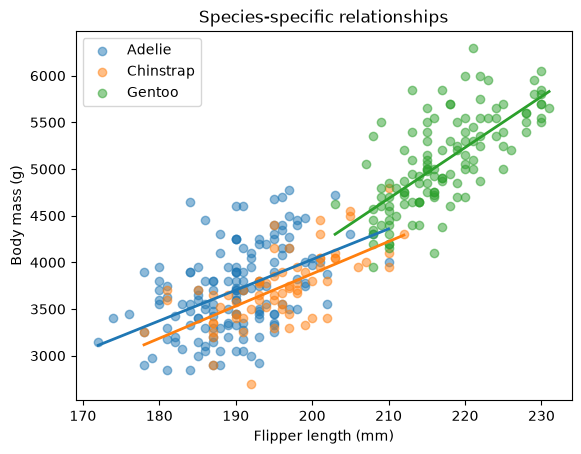

In [34]:
interaction_df = df[["flipper_length_mm", "body_mass_g", "species"]].dropna()

for species, group in interaction_df.groupby("species"):
    plt.scatter(group["flipper_length_mm"],
        group["body_mass_g"],
        alpha=0.5,
        label=species)

    species_model = LinearRegression()
    X_s = group[["flipper_length_mm"]]
    y_s = group["body_mass_g"]
    species_model.fit(X_s, y_s)

    x_grid = np.linspace(X_s["flipper_length_mm"].min(), X_s["flipper_length_mm"].max(), 100)

    y_grid = species_model.predict(pd.DataFrame({"flipper_length_mm": x_grid}))

    plt.plot(
        x_grid,
        y_grid,
        linewidth=2)

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Species-specific relationships")
plt.legend()
plt.show()

### Question

Are the regression lines approximately parallel?

A formal interaction model would explicitly include terms such as:

$$
\text{FlipperLength} \times \text{Species}
$$

# 13. Train/test evaluation

Until now, much of the analysis used the whole dataset.

For predictive ML, we need to evaluate generalization to unseen observations.

In [35]:
evaluation_df = df[
    ["flipper_length_mm","culmen_length_mm", "culmen_depth_mm", "species", "sex", "body_mass_g"]].dropna()

X = evaluation_df.drop(columns="body_mass_g")
y = evaluation_df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE)

## 13.1 Compare three models

We will compare:

1. flipper length only;
2. three numerical morphology variables;
3. morphology + species + sex.

In [36]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)}

In [37]:
results = []
# Model 1: flipper length only
m1 = LinearRegression()
m1.fit(X_train[["flipper_length_mm"]], y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test)]:
    pred = m1.predict(X_split[["flipper_length_mm"]])
    metrics = regression_metrics(y_split, pred)
    results.append({
        "model": "Flipper only",
        "split": split_name,
        **metrics })
metrics

{'MAE': 323.26928398908325,
 'MSE': 146853.34104290273,
 'RMSE': np.float64(383.2144843855758),
 'R2': 0.7421293782099881}

In [38]:
# Model 2: morphology
m2_features = [
    "flipper_length_mm",
    "culmen_length_mm",
    "culmen_depth_mm"]

m2 = LinearRegression()
m2.fit(X_train[m2_features], y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test)]:
    pred = m2.predict(X_split[m2_features])
    metrics = regression_metrics(y_split, pred)
    results.append({
        "model": "Morphology",
        "split": split_name,
        **metrics })
metrics

{'MAE': 320.38704846538485,
 'MSE': 146765.2985761208,
 'RMSE': np.float64(383.0995935473187),
 'R2': 0.7422839784764291}

In [39]:

# Model 3: morphology + categorical metadata
m3 = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearRegression())])

m3.fit(X_train, y_train)

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("test", X_test, y_test)]:
    pred = m3.predict(X_split)
    metrics = regression_metrics(y_split, pred)
    results.append({
        "model": "Morphology + species + sex",
        "split": split_name,
        **metrics})
metrics

{'MAE': 234.03791752912622,
 'MSE': 86992.6676717809,
 'RMSE': np.float64(294.945194352749),
 'R2': 0.8472431533093938}

In [40]:
results_df = pd.DataFrame(results)
results_df

,model,split,MAE,MSE,RMSE,R2
0,Flipper only,train,308.904907,155042.594609,393.754485,0.766608
1,Flipper only,test,323.269284,146853.341043,383.214484,0.742129
2,Morphology,train,306.859385,153800.268376,392.173773,0.768479
3,Morphology,test,320.387048,146765.298576,383.099594,0.742284
4,Morphology + species + sex,train,225.803076,79565.957979,282.074384,0.880226
5,Morphology + species + sex,test,234.037918,86992.667672,294.945194,0.847243


## 13.2 Focus on held-out performance

In [41]:
results_df[results_df["split"] == "test"].sort_values("RMSE")

,model,split,MAE,MSE,RMSE,R2
5,Morphology + species + sex,test,234.037918,86992.667672,294.945194,0.847243
3,Morphology,test,320.387048,146765.298576,383.099594,0.742284
1,Flipper only,test,323.269284,146853.341043,383.214484,0.742129


### Questions

- Which model has the lowest test RMSE?
- Which model has the highest test $R^2$?
- Does adding predictors always improve test performance?
- Are train and test scores similar?
- Which model would you choose if interpretability matters?

---

# 16. Independent student task — Diabetes regression

Now apply the same workflow to a different modality.

We use the scikit-learn **Diabetes** dataset.

The dataset contains baseline physiological measurements from patients and a quantitative target representing disease progression.

Your task is to prepare, fit, diagnose, and evaluate linear regression models without following step-by-step commands from the guided section.

In [42]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [43]:
diabetes_df.shape

(442, 11)

In [44]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## Student research question

> **Can baseline physiological measurements predict quantitative diabetes disease progression?**

## Required tasks

### A. Data presentation

Identify:

- one observation;
- target variable;
- predictor variables;
- dimensionality of the dataset.

### B. Descriptive analysis

- summarize the target;
- visualize its distribution;
- visualize at least three predictor–target relationships.

### C. Correlation

- calculate Pearson correlations;
- identify the predictor most strongly correlated with the target;
- compare at least one Pearson and Spearman result.

### D. Simple regression

Choose one predictor and fit:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

Report and interpret:

- intercept;
- slope.

### E. Residual diagnostics

Produce:

- observed vs predicted plot;
- residuals vs fitted plot;
- residual histogram;
- Q-Q plot.

Discuss:

- linearity;
- homoscedasticity;
- residual normality.

### F. Multiple regression

Fit a model using all available predictors.

Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity.

### G. Train/test evaluation

Create a train/test split and report:

- MAE;
- MSE;
- RMSE;
- $R^2$.

Compare simple and multiple regression on **test data**.

### H. Interpretation

Write a short Markdown conclusion answering:

1. Which model generalized better?
2. Did adding more variables help?
3. Are any regression assumptions questionable?
4. Are coefficient interpretations straightforward?
5. What is one important limitation of the dataset or model?